# Video RAG - 프레임 추출

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
BASE_PATH = 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag'

## 동영상 재생

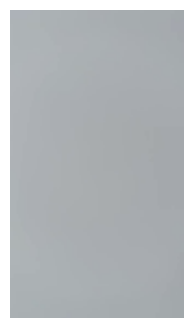

비디오 재생 완료!


In [6]:
import os
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

video_path = os.path.join(BASE_PATH, "videos", "skiing.mp4")

# 비디오 캡처 객체 생성
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f'비디오 파일을 열 수 없습니다.: {video_path}')

while cap.isOpened():
    # 프레임을 한 장씩 읽어온다
    ret, frame = cap.read()

    # 더 이상 읽을 프레임이 없으면 종료
    if not ret:
        print('비디오 재생 완료!')
        break

    # OpenCV는 BGR, matplotlib은 RGB 기준이므로 변환이 필요하다
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 이전 출력 결과를 지워 동영상 처럼 보이게 한다.
    clear_output(wait=True)

    plt.figure(figsize=(6, 4))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

cap.release()

## 동영상 정보 추출 함수 정의

video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\alpinist.mp4
frame_count=75
fps=25.0
duration=3.0


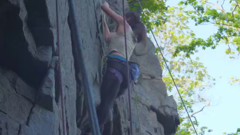


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\basketball.mp4
frame_count=90
fps=29.97002997002997
duration=3.003


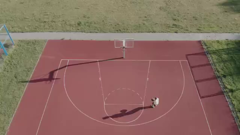


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\jogging.mp4
frame_count=75
fps=25.0
duration=3.0


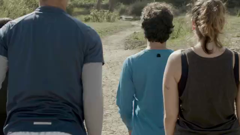


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\skiing.mp4
frame_count=180
fps=60.0
duration=3.0


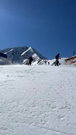


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\soccer.mp4
frame_count=75
fps=25.0
duration=3.0


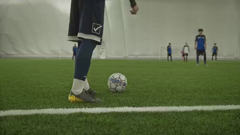


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\surfing.mp4
frame_count=72
fps=23.976023976023978
duration=3.0029999999999997


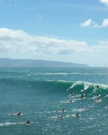


video_path=C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\videos\swimming.mp4
frame_count=75
fps=25.0
duration=3.0


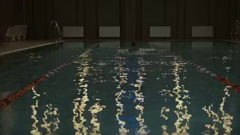

In [7]:
from PIL import Image 

def show_video_summary(base_path, video_dir, video_file, thumb_size=(240, 135)):
    video_path = os.path.join(base_path, video_dir, video_file)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"비디오를 열 수 없습니다. {video_path}")
    
    # 전체 프레임 수, FPS, 동영상 길이 확인
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps == 0:
        duration = 0
    else:
        duration = frame_count / fps

    print(f'video_path={video_path}')
    print(f'frame_count={frame_count}')
    print(f'fps={fps}')
    print(f'duration={duration}')

    # 첫 번째 프레임 읽기
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise ValueError(f"첫 번째 프레임을 읽을 수 없습니다. {video_path}")
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    thumbnail = Image.fromarray(frame_rgb)
    # 지정한 크기 안에서 원본 비율을 유지하며 축소
    thumbnail.thumbnail(thumb_size)

    display(thumbnail)

video_dir_path = os.path.join(BASE_PATH, "videos")
video_files = [
    file 
        for file in os.listdir(video_dir_path)
            if file.lower().endswith('.mp4')
]

for video_file in video_files:
    show_video_summary(BASE_PATH, "videos", video_file)
    print()

## 프레임 추출/저장

In [8]:
def extract_frames_from_videos(base_path, video_dir, frame_dir, frame_interval=1):
    """
    frame_interval: 몇 프레임마다 저장할지 설정. 기본 값 1이면 모든 프레임을 저장.
    """
    video_dir_path = os.path.join(base_path, video_dir)
    frame_dir_path = os.path.join(base_path, frame_dir)
    os.makedirs(frame_dir_path, exist_ok=True)
    video_files = [f for f in os.listdir(video_dir_path)]

    for idx_file, video_file in enumerate(video_files):
        # 비디오별 서브 디렉토리 생성
        video_path = os.path.join(video_dir_path, video_file)
        video_name = os.path.splitext(video_file)[0]    # (파일명, 확장자)
        video_subdir = os.path.join(frame_dir_path, video_name)
        os.makedirs(video_subdir, exist_ok=True)

        # 프레임 추출
        cap = cv2.VideoCapture(video_path)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        idx = 0
        saved_count = 0

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if idx % frame_interval == 0:   # frame_interval 마다 저장
                frame_path = os.path.join(video_subdir, f'{video_name}_frame{idx:05d}.jpg')
                cv2.imwrite(frame_path, frame)
                saved_count += 1
            idx += 1
        
        cap.release()
        print(f'{video_name} : 총 {frame_count} 프레임 중에 {saved_count}장 저장 되었습니다.')

extract_frames_from_videos(BASE_PATH, 'videos', 'frames', frame_interval=30)

alpinist : 총 75.0 프레임 중에 3장 저장 되었습니다.
basketball : 총 90.0 프레임 중에 3장 저장 되었습니다.
jogging : 총 75.0 프레임 중에 3장 저장 되었습니다.
skiing : 총 180.0 프레임 중에 6장 저장 되었습니다.
soccer : 총 75.0 프레임 중에 3장 저장 되었습니다.
surfing : 총 72.0 프레임 중에 3장 저장 되었습니다.
swimming : 총 75.0 프레임 중에 3장 저장 되었습니다.
